In [1]:
from langgraph.graph import START,END,StateGraph
from langchain_ollama import ChatOllama
from typing import TypedDict

In [2]:
llm =ChatOllama(model="llama3.2:1b ")

In [3]:
class Math_function(TypedDict):
    input_number:int
    square:int
    cube:int
    sqrt:int
    

In [5]:
def generate_square(state:Math_function):
    number=state["input_number"]
    return {
        "square":number**2
    }

def generate_cube(state:Math_function):
    number=state["input_number"]
    return {
        "cube":number**3
    }

def generate_sqrt(state:Math_function):
    number=state["input_number"]
    return {
        "sqrt":number**0.5
    }

In [6]:
graph=StateGraph(Math_function)

In [7]:
graph.add_node("generate_square",generate_square)
graph.add_node("generate_cube",generate_cube)
graph.add_node("generate_sqrt",generate_sqrt)
graph.add_edge(START,"generate_square")
graph.add_edge(START,"generate_cube")
graph.add_edge(START,"generate_sqrt")
graph.add_edge("generate_square",END)
graph.add_edge("generate_cube",END)
graph.add_edge("generate_sqrt",END)


In [8]:
app=graph.compile()


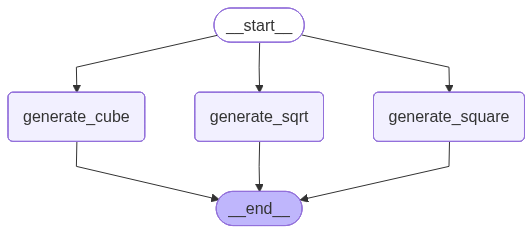

In [9]:
app

In [11]:
app.invoke({"input_number":144})


{'input_number': 144, 'square': 20736, 'cube': 2985984, 'sqrt': 12.0}